# Model Comparison Notebook
Compares **RandomForest vs XGBoost vs LightGBM vs CatBoost** 

In [1]:
!pip install xgboost lightgbm catboost
!pip install seaborn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
sys.path.insert(0, r"C:\Users\Rosa Daneshmandnia\predicting-global-conflict\forecast_model")

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from utils.preprocessing import prepare_data_pipeline
from config import settings

## 1. Load Data

In [3]:
model_data = pd.read_csv(r"C:\Users\Rosa Daneshmandnia\predicting-global-conflict\data\processed\model_data.csv")

model_data = model_data.set_index(['matched_admin1_id', 'month_year'])

model_data = model_data.sort_index()

print(f'Loaded: {model_data.shape[0]:,} rows x {model_data.shape[1]} cols')
model_data.info()
model_data.describe()

Loaded: 278,820 rows x 100 cols
<class 'pandas.DataFrame'>
MultiIndex: 278820 entries, ('ABW - Aruba', '2018-01') to (nan, '2025-06')
Data columns (total 100 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   Battles (t-1)                                275633 non-null  float64
 1   Explosions/Remote violence (t-1)             275633 non-null  float64
 2   Protests (t-1)                               275633 non-null  float64
 3   Riots (t-1)                                  275633 non-null  float64
 4   Strategic developments (t-1)                 275633 non-null  float64
 5   Violence against civilians (t-1)             275633 non-null  float64
 6   Excessive force against protesters (t-1)     275633 non-null  float64
 7   Agreement (t-1)                              275633 non-null  float64
 8   Explosions/Remote violence_neighbours (t-1)  275633 non-null  float64
 9   St

,Battles (t-1),Explosions/Remote violence (t-1),Protests (t-1),Riots (t-1),Strategic developments (t-1),Violence against civilians (t-1),Excessive force against protesters (t-1),Agreement (t-1),Explosions/Remote violence_neighbours (t-1),Strategic developments_neighbours (t-1),...,risk_military_coup,risk_natural_disaster,risk_political_assassination,risk_contested_election (t-1),risk_crop_failure (t-1),risk_economic_concern (t-1),risk_ethnic_tension (t-1),risk_military_coup (t-1),risk_natural_disaster (t-1),risk_political_assassination (t-1)
count,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,...,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000
mean,1.238741,1.409740,3.471569,0.481844,0.565821,0.856490,0.013707,0.009556,6.946316,2.895836,...,0.069260,0.350133,0.105297,0.099577,0.380432,0.247174,0.138634,0.068273,0.342364,0.099778
std,13.849694,23.869244,13.955840,5.851017,3.813787,4.079164,0.431490,0.165491,72.337224,12.018981,...,0.333235,1.146762,0.844635,0.489615,1.042766,0.675020,0.531955,0.331815,1.130166,0.831644
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1664.000000,1773.000000,715.000000,862.000000,286.000000,234.000000,119.000000,29.000000,3961.000000,464.000000,...,16.000000,37.000000,26.000000,12.000000,19.000000,31.000000,23.000000,16.000000,37.000000,26.000000


In [4]:
TEST_TARGETS = [
    'Battles',
    'Explosions/Remote violence',
    'Violence against civilians',
]

# Activity in last 6 months only
test_period_activity = (
    model_data
    .groupby('matched_admin1_id')[TEST_TARGETS]
    .apply(lambda x: x.iloc[-6:].sum().sum())
)

# Only keep regions that had at least some activity in test period
min_test_activity = 10  # just arbitrary
active_regions = test_period_activity[test_period_activity >= min_test_activity]
active_regions = active_regions.sort_values()

low  = active_regions.head(3).index.tolist()
mid  = active_regions.iloc[len(active_regions)//2 - 2 : len(active_regions)//2 + 2].index.tolist()
high = active_regions.tail(3).index.tolist()

TEST_REGIONS = low + mid + high

available     = model_data.index.get_level_values('matched_admin1_id').unique()
valid_regions = [r for r in TEST_REGIONS if r in available]
missing       = [r for r in TEST_REGIONS if r not in available]

if missing:
    print(f'Warning: these regions not found and will be skipped: {missing}')
print(f'Testing {len(valid_regions)} regions × {len(TEST_TARGETS)} targets = {len(valid_regions)*len(TEST_TARGETS)} runs')
print(f'\nRegions selected:')
for r in valid_regions:
    print(f'  {r} — test period activity: {test_period_activity[r]:.0f}')

Testing 10 regions × 3 targets = 30 runs

Regions selected:
  AFG - Baghlan — test period activity: 10
  VEN - Aragua — test period activity: 10
  VEN - Falcón — test period activity: 10
  JAM - Saint Catherine — test period activity: 42
  IND - Punjab — test period activity: 42
  YEM - Lahij — test period activity: 42
  UKR - Cherkasy — test period activity: 42
  RUS - Belgorod — test period activity: 5643
  UKR - Sumy — test period activity: 6740
  UKR - Donetsk — test period activity: 11045


## 3. Model Definitions

In [5]:
MODELS = {
    'RandomForest': RandomForestRegressor(
        n_estimators=100,
        random_state=42,
    ),
    'XGBoost': XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        verbosity=0
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        verbose=-1
    ),
    'CatBoost': CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=4,
        random_seed=42,
        verbose=0
    ),
}

## 4. Split

In [6]:
def encode_categoricals(X_train, X_test):
    X_train, X_test = X_train.copy(), X_test.copy()
    cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
    for col in cat_cols:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = X_test[col].astype(str).map(
            lambda x, le=le: le.transform([x])[0] if x in le.classes_ else -1
        )
    return X_train, X_test


def get_valid_predictors(df):
    base = [c for c in settings.predictors if c in df.columns and c != 'importance_weight']
    risk_cols = [c for c in df.columns if c.startswith('risk_') and c not in base]
    return base + risk_cols


def split_region_data(region_data):
    
    """
    Locked split identical to simple_model.py. Do not change.
    Train = everything except last 6 months
    Test  = last 6 months
    """
    
    train = region_data.iloc[:-6]
    test  = region_data.iloc[-6:]
    return train, test

## 5. Run Comparison

In [7]:
results = []
feature_importances = {}

feature_cols = get_valid_predictors(model_data)
print(f'Using {len(feature_cols)} predictor columns\n')

for region in valid_regions:
    region_data = model_data.loc[region].sort_index()

    if len(region_data) < 12:
        print(f'Skipping {region}: only {len(region_data)} months of data')
        continue

    train_data, test_data = split_region_data(region_data)

    # RF needs fillna (sklearn cannot handle NaN)
    X_train_filled = train_data[feature_cols].fillna(0)
    X_test_filled  = test_data[feature_cols].fillna(0)

    # XGBoost, LightGBM, CatBoost handle NaN natively(keeping raw)
    X_train_raw = train_data[feature_cols]
    X_test_raw  = test_data[feature_cols]

    weights = train_data['importance_weight']

    X_train_filled_enc, X_test_filled_enc = encode_categoricals(X_train_filled, X_test_filled)
    X_train_raw_enc,    X_test_raw_enc    = encode_categoricals(X_train_raw,    X_test_raw)

    for target in TEST_TARGETS:
        if target not in region_data.columns:
            continue

        y_train = train_data[target]
        y_test  = test_data[target]

        if y_train.sum() == 0 and y_test.sum() == 0:
            continue

        for model_name, model in MODELS.items():
            try:
                # Use filled data for RF, raw for the rest
                if model_name == 'RandomForest':
                    X_tr, X_te = X_train_filled_enc, X_test_filled_enc
                else:
                    X_tr, X_te = X_train_raw_enc, X_test_raw_enc

                model.fit(X_tr, y_train, sample_weight=weights.values)
                y_pred = np.clip(model.predict(X_te), 0, None)

                mae     = mean_absolute_error(y_test, y_pred)
                nonzero = y_test != 0
                mape    = (
                    np.abs((y_test[nonzero] - y_pred[nonzero]) / y_test[nonzero]).mean() * 100
                    if nonzero.sum() > 0 else np.nan
                )

                results.append({
                    'region':      region,
                    'target':      target,
                    'model':       model_name,
                    'mae':         mae,
                    'mape':        mape,
                    'n_test':      len(y_test),
                    'mean_actual': y_test.mean(),
                })

                if hasattr(model, 'feature_importances_'):
                    feature_importances[(model_name, region, target)] = pd.Series(
                        model.feature_importances_, index=feature_cols
                    )

            except Exception as e:
                print(f'  ERROR: {model_name} / {region} / {target}: {e}')

results_df = pd.DataFrame(results)
print(f'\nDone! {len(results_df)} results collected.')
results_df.sort_values('mean_actual', ascending=False).head(20)

Using 95 predictor columns


Done! 112 results collected.


,region,target,model,mae,mape,n_test,mean_actual
100,UKR - Donetsk,Battles,RandomForest,272.066667,18.976809,6,1323.166667
101,UKR - Donetsk,Battles,XGBoost,267.221375,18.653730,6,1323.166667
102,UKR - Donetsk,Battles,LightGBM,301.499730,20.919753,6,1323.166667
103,UKR - Donetsk,Battles,CatBoost,229.565073,15.803616,6,1323.166667
92,UKR - Sumy,Explosions/Remote violence,RandomForest,181.443333,15.889868,6,1079.166667
93,UKR - Sumy,Explosions/Remote violence,XGBoost,219.814224,22.181945,6,1079.166667
94,UKR - Sumy,Explosions/Remote violence,LightGBM,370.116565,33.729763,6,1079.166667
95,UKR - Sumy,Explosions/Remote violence,CatBoost,169.829217,14.823171,6,1079.166667
80,RUS - Belgorod,Explosions/Remote violence,RandomForest,193.481667,19.809973,6,926.500000
81,RUS - Belgorod,Explosions/Remote violence,XGBoost,205.936020,21.863044,6,926.500000


## 6. Summary Table — MAE by Model

In [8]:
# Average MAE per model per target
summary = results_df.groupby(['model', 'target'])['mae'].mean().unstack('target').round(3)
summary['AVERAGE'] = summary.mean(axis=1)
summary = summary.sort_values('AVERAGE')

print('=== Mean MAE across all tested regions ===\n')
print(summary.to_string())
print('\n(Lower is better)')

=== Mean MAE across all tested regions ===

target        Battles  Explosions/Remote violence  Violence against civilians    AVERAGE
model                                                                                   
RandomForest   37.523                      49.307                       1.533  29.454333
CatBoost       32.833                      54.939                       1.412  29.728000
XGBoost        37.213                      55.542                       1.717  31.490667
LightGBM       41.465                      75.290                       1.275  39.343333

(Lower is better)


## 7. Visualisation — MAE Comparison

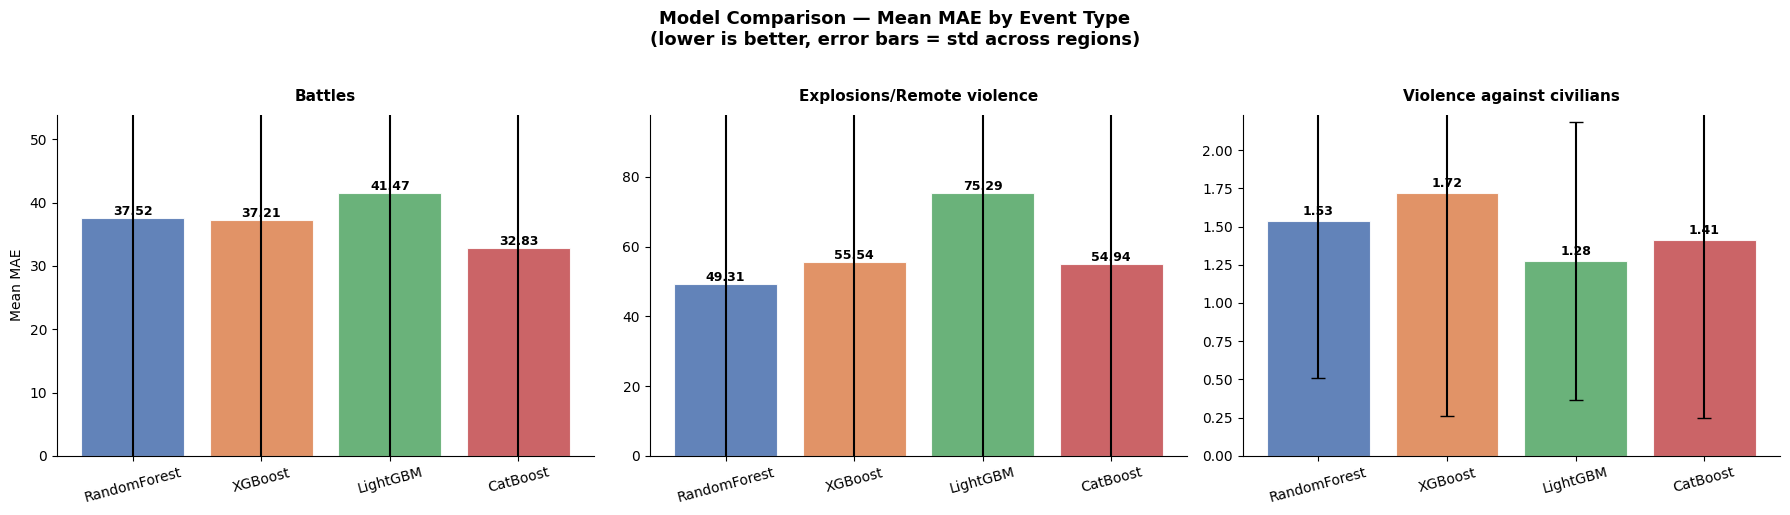

In [9]:
MODEL_COLORS = {
    'RandomForest': '#4C72B0',
    'XGBoost':      '#DD8452',
    'LightGBM':     '#55A868',
    'CatBoost':     '#C44E52',
}

fig, axes = plt.subplots(1, len(TEST_TARGETS), figsize=(6 * len(TEST_TARGETS), 5), sharey=False)
if len(TEST_TARGETS) == 1:
    axes = [axes]

for ax, target in zip(axes, TEST_TARGETS):
    subset = results_df[results_df['target'] == target]
    model_means = subset.groupby('model')['mae'].mean().reindex(MODELS.keys())
    model_stds  = subset.groupby('model')['mae'].std().reindex(MODELS.keys())

    colors = [MODEL_COLORS[m] for m in model_means.index]
    bars = ax.bar(model_means.index, model_means.values, color=colors,
                  yerr=model_stds.values, capsize=5, alpha=0.88, edgecolor='white', linewidth=0.8)

    for bar, val in zip(bars, model_means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(target, fontsize=11, fontweight='bold', pad=10)
    ax.set_ylabel('Mean MAE' if ax == axes[0] else '')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0, model_means.max() * 1.3)

fig.suptitle('Model Comparison — Mean MAE by Event Type\n(lower is better, error bars = std across regions)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Visualisation — Per-Region Heatmap

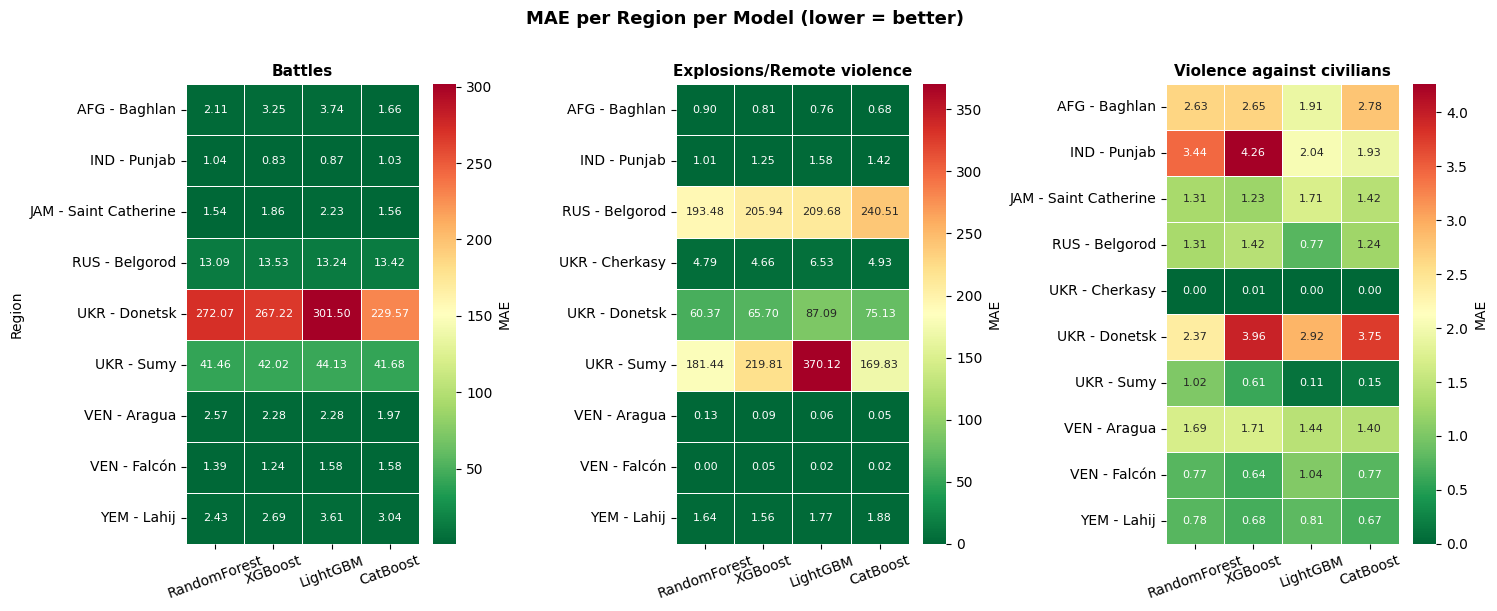

In [10]:
fig, axes = plt.subplots(1, len(TEST_TARGETS), figsize=(5 * len(TEST_TARGETS), max(4, len(valid_regions) * 0.6)))
if len(TEST_TARGETS) == 1:
    axes = [axes]

for ax, target in zip(axes, TEST_TARGETS):
    subset = results_df[results_df['target'] == target]
    pivot  = subset.pivot(index='region', columns='model', values='mae').round(2)
    pivot  = pivot.reindex(columns=list(MODELS.keys()))

    sns.heatmap(
        pivot, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn_r',
        linewidths=0.5, cbar_kws={'label': 'MAE'},
        annot_kws={'size': 8}
    )
    ax.set_title(target, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Region' if ax == axes[0] else '')
    ax.tick_params(axis='x', rotation=20)
    ax.tick_params(axis='y', rotation=0)

fig.suptitle('MAE per Region per Model (lower = better)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Visualisation — Win Rate (How Often Each Model Wins)

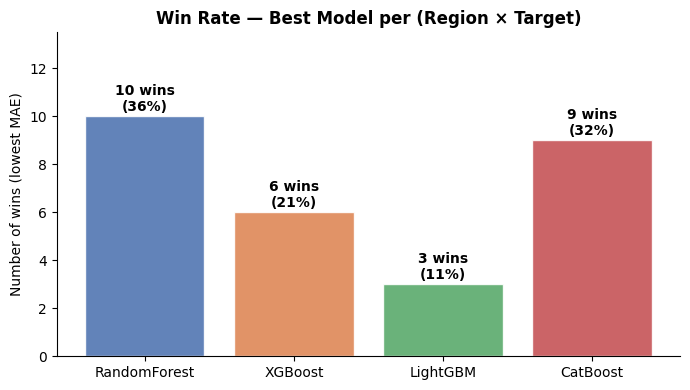

In [11]:
# For each (region, target) pair — which model had the lowest MAE?
winners = (
    results_df
    .loc[results_df.groupby(['region', 'target'])['mae'].idxmin()]
    ['model']
    .value_counts()
    .reindex(MODELS.keys(), fill_value=0)
)

fig, ax = plt.subplots(figsize=(7, 4))
colors = [MODEL_COLORS[m] for m in winners.index]
bars = ax.bar(winners.index, winners.values, color=colors, alpha=0.88, edgecolor='white')

total = winners.sum()
for bar, val in zip(bars, winners.values):
    pct = 100 * val / total
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val} wins\n({pct:.0f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Win Rate — Best Model per (Region × Target)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of wins (lowest MAE)')
ax.set_ylim(0, winners.max() * 1.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 10. Feature Importance — Top 15 Features (Best Model)

Best overall model: RandomForest


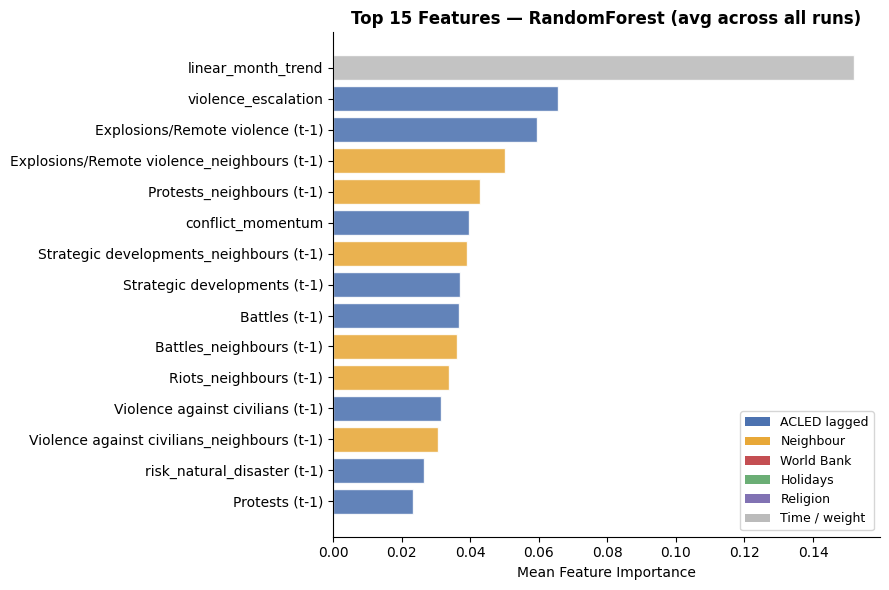

In [12]:
# Pick the overall best model by average MAE
best_model_name = results_df.groupby('model')['mae'].mean().idxmin()
print(f'Best overall model: {best_model_name}')

# Aggregate feature importances across all runs of best model
fi_list = [
    fi for (m, r, t), fi in feature_importances.items()
    if m == best_model_name
]

if fi_list:
    avg_fi = pd.concat(fi_list, axis=1).mean(axis=1).sort_values(ascending=True)
    top15  = avg_fi.tail(15)

    # Colour bars by feature group
    def get_feature_group_color(feat):
        if 'neighbour' in feat.lower():       return '#E8A838'
        if 'holiday' in feat.lower():          return '#6BAE75'
        if any(x in feat.lower() for x in ['inflation','unemployment','inequality','income']): return '#C44E52'
        if any(x in feat.lower() for x in ['majority','minority','religion','nonrelig']):     return '#8172B3'
        if any(x in feat.lower() for x in ['month','year','quarter','trend','weight']):       return '#BBBBBB'
        return '#4C72B0'  # ACLED lagged events

    colors = [get_feature_group_color(f) for f in top15.index]

    fig, ax = plt.subplots(figsize=(9, 6))
    bars = ax.barh(top15.index, top15.values, color=colors, alpha=0.88, edgecolor='white')
    ax.set_title(f'Top 15 Features — {best_model_name} (avg across all runs)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean Feature Importance')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#4C72B0', label='ACLED lagged'),
        Patch(facecolor='#E8A838', label='Neighbour'),
        Patch(facecolor='#C44E52', label='World Bank'),
        Patch(facecolor='#6BAE75', label='Holidays'),
        Patch(facecolor='#8172B3', label='Religion'),
        Patch(facecolor='#BBBBBB', label='Time / weight'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('No feature importances collected — check model runs.')

## 11. Feature Importance (CatBoost Deep Dive)

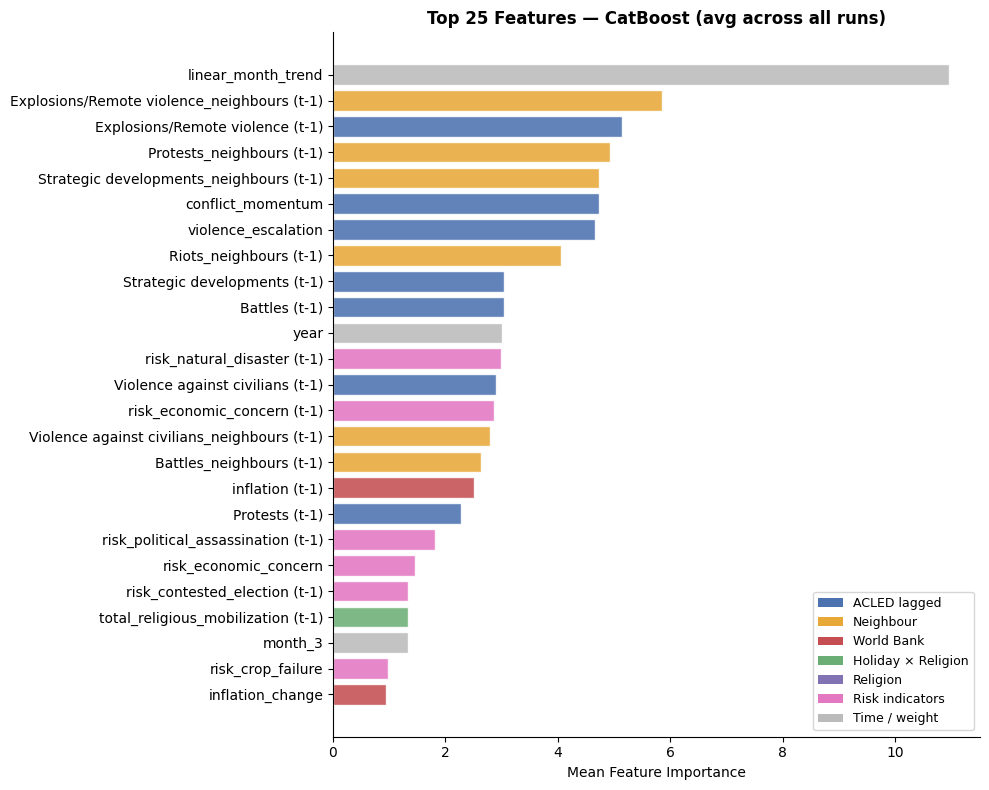

In [20]:
fi_list = [fi for (m, r, t), fi in feature_importances.items() if m == 'CatBoost']
avg_fi = pd.concat(fi_list, axis=1).mean(axis=1).sort_values(ascending=True)
top20 = avg_fi.tail(25)

def get_feature_group_color(feat):
    if 'neighbour' in feat.lower():      return '#E8A838'
    if any(x in feat.lower() for x in ['weighted_holiday', 'tension', 'mobilization']): return '#6BAE75'
    if any(x in feat.lower() for x in ['inflation','unemployment','inequality','income']): return '#C44E52'
    if any(x in feat.lower() for x in ['majority','minority','religion','nonrelig']): return '#8172B3'
    if any(x in feat.lower() for x in ['month','year','quarter','trend']): return '#BBBBBB'
    if 'risk' in feat.lower():           return '#E377C2'
    return '#4C72B0'

colors = [get_feature_group_color(f) for f in top20.index]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top20.index, top20.values, color=colors, alpha=0.88, edgecolor='white')
ax.set_title('Top 25 Features — CatBoost (avg across all runs)', fontsize=12, fontweight='bold')
ax.set_xlabel('Mean Feature Importance')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='ACLED lagged'),
    Patch(facecolor='#E8A838', label='Neighbour'),
    Patch(facecolor='#C44E52', label='World Bank'),
    Patch(facecolor='#6BAE75', label='Holiday × Religion'),
    Patch(facecolor='#8172B3', label='Religion'),
    Patch(facecolor='#E377C2', label='Risk indicators'),
    Patch(facecolor='#BBBBBB', label='Time / weight'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

**we freeze the base and continue more exploring our promising candidate : catboost**

## 12.CatBoost Proper Setup

In [23]:
# let it handle categorical cols natively instead of LabelEncoder

CB_NATIVE_PARAMS = dict(
    iterations=500,
    learning_rate=0.05,
    depth=4,
    random_seed=42,
    verbose=0
)

cb_feature_cols = get_valid_predictors(model_data)

cat_cols = model_data[cb_feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()

if 'income_level_code (t-1)' in cb_feature_cols and 'income_level_code (t-1)' not in cat_cols:
    cat_cols.append('income_level_code (t-1)')

print(f"Using {len(cb_feature_cols)} predictor columns")
print("CatBoost categorical columns:", cat_cols)

Using 95 predictor columns
CatBoost categorical columns: ['majority_religion', 'minority1_religion', 'minority2_religion', 'income_level_code (t-1)']


In [24]:
# native categoricals, raw NaNs
cb_native_results = []
cb_native_feature_importances = {}

for region in valid_regions:
    region_data = model_data.loc[region].sort_index()

    if len(region_data) < 12:
        print(f"Skipping {region}: only {len(region_data)} months of data")
        continue

    train_data, test_data = split_region_data(region_data)

    X_train = train_data[cb_feature_cols].copy()
    X_test  = test_data[cb_feature_cols].copy()

    bool_cols = X_train.select_dtypes(include=['bool']).columns.tolist()
    for col in bool_cols:
        X_train[col] = X_train[col].astype(int)
        X_test[col]  = X_test[col].astype(int)

    for col in cat_cols:
        X_train[col] = X_train[col].fillna('__MISSING__').astype(str)
        X_test[col]  = X_test[col].fillna('__MISSING__').astype(str)

    weights = train_data['importance_weight']

    for target in TEST_TARGETS:
        if target not in region_data.columns:
            continue

        y_train = train_data[target]
        y_test  = test_data[target]

        if y_train.sum() == 0 and y_test.sum() == 0:
            continue

        try:
            model = CatBoostRegressor(**CB_NATIVE_PARAMS)

            model.fit(
                X_train,
                y_train,
                cat_features=cat_cols,
                sample_weight=weights.values
            )

            y_pred = np.clip(model.predict(X_test), 0, None)

            mae = mean_absolute_error(y_test, y_pred)
            nonzero = y_test != 0
            mape = (
                np.abs((y_test[nonzero] - y_pred[nonzero]) / y_test[nonzero]).mean() * 100
                if nonzero.sum() > 0 else np.nan
            )

            cb_native_results.append({
                'region': region,
                'target': target,
                'model': 'CatBoost_native',
                'mae': mae,
                'mape': mape,
                'n_test': len(y_test),
                'mean_actual': y_test.mean(),
            })

            cb_native_feature_importances[(region, target)] = pd.Series(
                model.feature_importances_,
                index=cb_feature_cols
            )

        except Exception as e:
            print(f"ERROR: CatBoost_native / {region} / {target}: {e}")

cb_native_results_df = pd.DataFrame(cb_native_results)

print(f"\nDone! {len(cb_native_results_df)} CatBoost-native results collected.")
cb_native_results_df.sort_values('mean_actual', ascending=False).head(20)


Done! 28 CatBoost-native results collected.


,region,target,model,mae,mape,n_test,mean_actual
25,UKR - Donetsk,Battles,CatBoost_native,231.428879,15.910262,6,1323.166667
23,UKR - Sumy,Explosions/Remote violence,CatBoost_native,190.765290,16.032607,6,1079.166667
20,RUS - Belgorod,Explosions/Remote violence,CatBoost_native,255.878880,26.512445,6,926.500000
26,UKR - Donetsk,Explosions/Remote violence,CatBoost_native,67.511249,14.523348,6,516.500000
22,UKR - Sumy,Battles,CatBoost_native,42.201259,81.712316,6,44.166667
19,RUS - Belgorod,Battles,CatBoost_native,13.254714,95.567919,6,13.666667
17,UKR - Cherkasy,Explosions/Remote violence,CatBoost_native,5.129188,70.802602,6,7.000000
14,YEM - Lahij,Battles,CatBoost_native,3.315903,77.471886,6,4.000000
9,JAM - Saint Catherine,Battles,CatBoost_native,1.547864,42.438064,6,3.666667
13,IND - Punjab,Violence against civilians,CatBoost_native,2.194970,85.842016,6,3.500000


In [25]:
# Compare old CatBoost vs CatBoost_native

old_cb_results_df = results_df[results_df['model'] == 'CatBoost'].copy()

compare_cb_df = pd.concat([
    old_cb_results_df,
    cb_native_results_df
], ignore_index=True)

print("Old CatBoost rows:", len(old_cb_results_df))
print("Native CatBoost rows:", len(cb_native_results_df))
print("Combined rows:", len(compare_cb_df))

compare_cb_df.head()

Old CatBoost rows: 28
Native CatBoost rows: 28
Combined rows: 56


,region,target,model,mae,mape,n_test,mean_actual
0,AFG - Baghlan,Battles,CatBoost,1.655795,96.191657,6,0.666667
1,AFG - Baghlan,Explosions/Remote violence,CatBoost,0.676358,57.197025,6,0.666667
2,AFG - Baghlan,Violence against civilians,CatBoost,2.781143,123.599370,6,0.333333
3,VEN - Aragua,Battles,CatBoost,1.970969,82.662715,6,1.666667
4,VEN - Aragua,Explosions/Remote violence,CatBoost,0.049247,NaN,6,0.000000


=== Mean MAE: CatBoost vs CatBoost_native ===

target           Battles  Explosions/Remote violence  Violence against civilians    AVERAGE
model                                                                                      
CatBoost          32.833                      54.939                       1.412  29.728000
CatBoost_native   33.110                      58.116                       1.431  30.885667

(Lower is better)


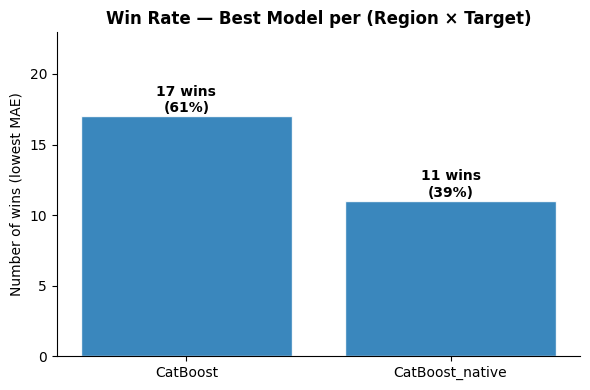

In [35]:
# Compare old CatBoost vs CatBoost_native

compare_cb_native_df = pd.concat([
    old_cb_results_df,
    cb_native_results_df
], ignore_index=True)

# Summary table
summary_cb_native = (
    compare_cb_native_df.groupby(['model', 'target'])['mae']
    .mean()
    .unstack('target')
    .round(3)
)
summary_cb_native['AVERAGE'] = summary_cb_native.mean(axis=1)
summary_cb_native = summary_cb_native.sort_values('AVERAGE')

print("=== Mean MAE: CatBoost vs CatBoost_native ===\n")
print(summary_cb_native.to_string())
print("\n(Lower is better)")

# Win rate
winners_cb_native = (
    compare_cb_native_df
    .loc[compare_cb_native_df.groupby(['region', 'target'])['mae'].idxmin()]
    ['model']
    .value_counts()
    .reindex(['CatBoost', 'CatBoost_native'], fill_value=0)
)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(winners_cb_native.index, winners_cb_native.values, alpha=0.88, edgecolor='white')

total = winners_cb_native.sum()
for bar, val in zip(bars, winners_cb_native.values):
    pct = 100 * val / total
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val} wins\n({pct:.0f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Win Rate — Best Model per (Region × Target)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of wins (lowest MAE)')
ax.set_ylim(0, winners_cb_native.max() * 1.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [31]:
 #NaN Handling 

CB_FILLNA_PARAMS = dict(
    iterations=500,
    learning_rate=0.05,
    depth=4,
    random_seed=42,
    verbose=0
)

cb_fillna_feature_cols = get_valid_predictors(model_data)

print(f"Using {len(cb_fillna_feature_cols)} predictor columns")

cb_fillna_results = []
cb_fillna_feature_importances = {}

for region in valid_regions:
    region_data = model_data.loc[region].sort_index()

    if len(region_data) < 12:
        print(f"Skipping {region}: only {len(region_data)} months of data")
        continue

    train_data, test_data = split_region_data(region_data)

    X_train = train_data[cb_fillna_feature_cols].copy()
    X_test  = test_data[cb_fillna_feature_cols].copy()

    # fill NaN only in numeric/bool columns
    num_bool_cols = X_train.select_dtypes(include=['number', 'bool']).columns.tolist()
    X_train[num_bool_cols] = X_train[num_bool_cols].fillna(0)
    X_test[num_bool_cols]  = X_test[num_bool_cols].fillna(0)

    # keep same encoded-categorical setup as old CatBoost baseline
    X_train_enc, X_test_enc = encode_categoricals(X_train, X_test)

    weights = train_data['importance_weight']

    for target in TEST_TARGETS:
        if target not in region_data.columns:
            continue

        y_train = train_data[target]
        y_test  = test_data[target]

        if y_train.sum() == 0 and y_test.sum() == 0:
            continue

        try:
            model = CatBoostRegressor(**CB_FILLNA_PARAMS)

            model.fit(X_train_enc, y_train, sample_weight=weights.values)
            y_pred = np.clip(model.predict(X_test_enc), 0, None)

            mae = mean_absolute_error(y_test, y_pred)
            nonzero = y_test != 0
            mape = (
                np.abs((y_test[nonzero] - y_pred[nonzero]) / y_test[nonzero]).mean() * 100
                if nonzero.sum() > 0 else np.nan
            )

            cb_fillna_results.append({
                'region': region,
                'target': target,
                'model': 'CatBoost_fillna0',
                'mae': mae,
                'mape': mape,
                'n_test': len(y_test),
                'mean_actual': y_test.mean(),
            })

            cb_fillna_feature_importances[(region, target)] = pd.Series(
                model.feature_importances_, index=cb_fillna_feature_cols
            )

        except Exception as e:
            print(f"ERROR: CatBoost_fillna0 / {region} / {target}: {e}")

cb_fillna_results_df = pd.DataFrame(cb_fillna_results)

print(f"\nDone! {len(cb_fillna_results_df)} CatBoost-fillna(0) results collected.")
cb_fillna_results_df.sort_values('mean_actual', ascending=False).head(20)

Using 95 predictor columns

Done! 28 CatBoost-fillna(0) results collected.


,region,target,model,mae,mape,n_test,mean_actual
25,UKR - Donetsk,Battles,CatBoost_fillna0,247.642808,17.231756,6,1323.166667
23,UKR - Sumy,Explosions/Remote violence,CatBoost_fillna0,181.674665,15.875876,6,1079.166667
20,RUS - Belgorod,Explosions/Remote violence,CatBoost_fillna0,219.704867,22.767521,6,926.500000
26,UKR - Donetsk,Explosions/Remote violence,CatBoost_fillna0,70.569207,14.668939,6,516.500000
22,UKR - Sumy,Battles,CatBoost_fillna0,42.282381,83.528965,6,44.166667
19,RUS - Belgorod,Battles,CatBoost_fillna0,13.365009,96.141256,6,13.666667
17,UKR - Cherkasy,Explosions/Remote violence,CatBoost_fillna0,4.899600,67.174135,6,7.000000
14,YEM - Lahij,Battles,CatBoost_fillna0,2.907791,66.514156,6,4.000000
9,JAM - Saint Catherine,Battles,CatBoost_fillna0,1.580697,48.410182,6,3.666667
13,IND - Punjab,Violence against civilians,CatBoost_fillna0,1.989914,79.732360,6,3.500000


=== Mean MAE: CatBoost vs CatBoost_fillna0 ===

target            Battles  Explosions/Remote violence  Violence against civilians    AVERAGE
model                                                                                       
CatBoost           32.833                      54.939                       1.412  29.728000
CatBoost_fillna0   34.874                      53.448                       1.365  29.895667

(Lower is better)


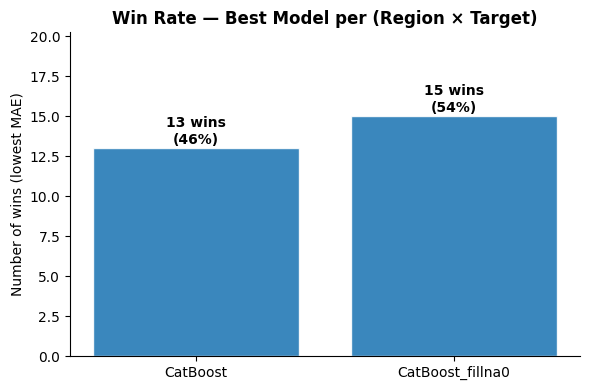

In [34]:
# Compare old CatBoost vs CatBoost_fillna0

old_cb_results_df = results_df[results_df['model'] == 'CatBoost'].copy()

compare_cb_nan_df = pd.concat([
    old_cb_results_df,
    cb_fillna_results_df
], ignore_index=True)

# Summary table
summary_cb_nan = (
    compare_cb_nan_df.groupby(['model', 'target'])['mae']
    .mean()
    .unstack('target')
    .round(3)
)
summary_cb_nan['AVERAGE'] = summary_cb_nan.mean(axis=1)
summary_cb_nan = summary_cb_nan.sort_values('AVERAGE')

print("=== Mean MAE: CatBoost vs CatBoost_fillna0 ===\n")
print(summary_cb_nan.to_string())
print("\n(Lower is better)")

# Win rate
winners_cb_nan = (
    compare_cb_nan_df
    .loc[compare_cb_nan_df.groupby(['region', 'target'])['mae'].idxmin()]
    ['model']
    .value_counts()
    .reindex(['CatBoost', 'CatBoost_fillna0'], fill_value=0)
)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(winners_cb_nan.index, winners_cb_nan.values, alpha=0.88, edgecolor='white')

total = winners_cb_nan.sum()
for bar, val in zip(bars, winners_cb_nan.values):
    pct = 100 * val / total
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val} wins\n({pct:.0f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Win Rate — Best Model per (Region × Target)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of wins (lowest MAE)')
ax.set_ylim(0, winners_cb_nan.max() * 1.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

=== Mean MAE: RandomForest vs CatBoost_fillna0 ===

target            Battles  Explosions/Remote violence  Violence against civilians    AVERAGE
model                                                                                       
RandomForest       37.523                      49.307                       1.533  29.454333
CatBoost_fillna0   34.874                      53.448                       1.365  29.895667

(Lower is better)


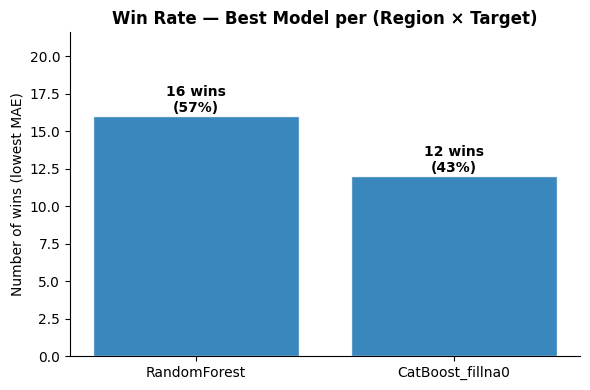

In [33]:
# RF vs CatBoost_fillna0

compare_df = pd.concat([
    results_df[results_df['model'] == 'RandomForest'].copy(),
    cb_fillna_results_df.copy()
], ignore_index=True)

# Summary table
summary = compare_df.groupby(['model', 'target'])['mae'].mean().unstack('target').round(3)
summary['AVERAGE'] = summary.mean(axis=1)
summary = summary.sort_values('AVERAGE')

print("=== Mean MAE: RandomForest vs CatBoost_fillna0 ===\n")
print(summary.to_string())
print("\n(Lower is better)")

# Win rate
winners = (
    compare_df
    .loc[compare_df.groupby(['region', 'target'])['mae'].idxmin()]
    ['model']
    .value_counts()
    .reindex(['RandomForest', 'CatBoost_fillna0'], fill_value=0)
)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(winners.index, winners.values, alpha=0.88, edgecolor='white')

total = winners.sum()
for bar, val in zip(bars, winners.values):
    pct = 100 * val / total
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val} wins\n({pct:.0f}%)', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.set_title('Win Rate — Best Model per (Region × Target)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of wins (lowest MAE)')
ax.set_ylim(0, winners.max() * 1.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [16]:
#NAN testung result
#Cell 13 — [EXPERIMENT 2] Global Model (all regions, region as feature)
#Cell 14 — [EXPERIMENT 2] Results — vs per-region baselin
#-------#
#Cell 13 — Run CatBoost with native categoricals + raw NaNs
#Cell 14 — Results vs frozen baseline
#Cell 15 — Feature Importance (CatBoost Proper)

## 11. Detailed Results Table

In [17]:
# Full results sorted by region + target + MAE
display_df = results_df.sort_values(['region', 'target', 'mae'])
display_df = display_df[['region', 'target', 'model', 'mae', 'mape', 'mean_actual']].round(3)
display_df.columns = ['Region', 'Target', 'Model', 'MAE', 'MAPE (%)', 'Mean Actual']

# Highlight best model per group
def highlight_best(group):
    min_mae = group['MAE'].min()
    return ['background-color: #d4edda' if v == min_mae else '' for v in group['MAE']]

display_df.style.apply(
    lambda g: highlight_best(g), subset=['MAE'],
    axis=0
).format({'MAE': '{:.3f}', 'MAPE (%)': '{:.1f}', 'Mean Actual': '{:.1f}'})

AttributeError: The '.style' accessor requires jinja2

## 12. Save Results to CSV

In [ ]:
import os
os.makedirs('outputs/results', exist_ok=True)
results_df.to_csv('outputs/results/model_comparison_results.csv', index=False)
print('Saved: outputs/results/model_comparison_results.csv')

print('\n=== Final Summary ===')
print(summary.to_string())
print(f'\n→ Best overall model: {best_model_name}')